In [ ]:
import pandas as pd

import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split,GridSearchCV,RandomizedSearchCV
from sklearn.svm import SVC as svc
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
from scipy import stats

import matplotlib.pyplot as plt
from sklearn import tree

import os

In [ ]:
df = pd.read_csv('smart_grid_stability_augmented.csv')
print("Dataset 'smart_grid_stability_augmented.csv' loaded successfully!")
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

Dataset 'smart_grid_stability_augmented.csv' loaded successfully!


In [3]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [5]:
DT = tree.DecisionTreeClassifier(random_state=1024)

In [6]:
grid_list = {'max_features': ['auto', 'sqrt', 'log2'],
              'ccp_alpha': [0.1, .01, .001],
              'max_depth' : [3, 4, 5, 6, 7, 8, 9],
              'criterion' :['gini', 'entropy']
             }
DT_grid = GridSearchCV(estimator=DT,param_grid=grid_list,n_jobs=4,refit=True,verbose=3,cv=5)
DT_grid.fit(X_train,y_train)

Fitting 5 folds for each of 126 candidates, totalling 630 fits
[CV 2/5] END ccp_alpha=0.1, criterion=gini, max_depth=3, max_features=auto;, score=nan total time=   0.0s
[CV 2/5] END ccp_alpha=0.1, criterion=gini, max_depth=3, max_features=sqrt;, score=1.000 total time=   0.1s
[CV 1/5] END ccp_alpha=0.1, criterion=gini, max_depth=3, max_features=log2;, score=1.000 total time=   0.1s
[CV 5/5] END ccp_alpha=0.1, criterion=gini, max_depth=3, max_features=log2;, score=1.000 total time=   0.1s
[CV 4/5] END ccp_alpha=0.1, criterion=gini, max_depth=4, max_features=sqrt;, score=1.000 total time=   0.1s
[CV 3/5] END ccp_alpha=0.1, criterion=gini, max_depth=4, max_features=log2;, score=1.000 total time=   0.1s
[CV 3/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=auto;, score=nan total time=   0.0s
[CV 5/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=auto;, score=nan total time=   0.0s
[CV 2/5] END ccp_alpha=0.1, criterion=gini, max_depth=5, max_features=sqrt;, sc

/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
210 fits failed out of a total of 630.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
172 fits failed with the following error:
Traceback (most recent call last):
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/base.py", line 1356, in wrapper
    estimator._validate_params()
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/base.py", line 469, in _validate_params
    validate_parameter_const

,estimator,DecisionTreeC...om_state=1024)
,param_grid,"{'ccp_alpha': [0.1, 0.01, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 4, ...], 'max_features': ['auto', 'sqrt', ...]}"
,scoring,None
,n_jobs,4
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [7]:
print('Mean Accuracy: %.2f %%'%(DT_grid.best_score_*100))
print('Best Parameters',DT_grid.best_params_)

Mean Accuracy: 100.00 %
Best Parameters {'ccp_alpha': 0.1, 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt'}


In [8]:
best_DT_grid = DT_grid.best_estimator_
y_pred = best_DT_grid.predict(X_test)

In [9]:
print(classification_report(y_test,y_pred))
print('confusion matrix:=\n',confusion_matrix(y_test,y_pred))
print('\nAccuracy:=',accuracy_score(y_test,y_pred)*100)
print('Precision:=',precision_score(y_test,y_pred,average='macro')*100)
print('Recall:=',recall_score(y_test,y_pred,average='macro')*100)
print('F1:=',f1_score(y_test,y_pred,average='macro')*100)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6522
           1       1.00      1.00      1.00     11478

    accuracy                           1.00     18000
   macro avg       1.00      1.00      1.00     18000
weighted avg       1.00      1.00      1.00     18000

confusion matrix:=
 [[ 6522     0]
 [    0 11478]]

Accuracy:= 100.0
Precision:= 100.0
Recall:= 100.0
F1:= 100.0


In [10]:
rand_list = {
    "ccp_alpha": stats.uniform(0.001, 0.1),
    "max_depth": range(3, 10),
    'max_features': ['auto', 'sqrt', 'log2'],
    'criterion' :['gini', 'entropy']
}

DT_rand = RandomizedSearchCV(DT,param_distributions=rand_list,n_iter=500,n_jobs=4,refit=True,verbose=3,cv=5) 
DT_rand.fit(X_train,y_train)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits

[CV 5/5] END ccp_alpha=0.01, criterion=entropy, max_depth=4, max_features=sqrt;, score=1.000 total time=   0.1s
[CV 5/5] END ccp_alpha=0.01, criterion=entropy, max_depth=6, max_features=auto;, score=nan total time=   0.0s
[CV 1/5] END ccp_alpha=0.01, criterion=entropy, max_depth=6, max_features=sqrt;, score=1.000 total time=   0.1s
[CV 2/5] END ccp_alpha=0.01, criterion=entropy, max_depth=6, max_features=sqrt;, score=1.000 total time=   0.1s
[CV 3/5] END ccp_alpha=0.01, criterion=entropy, max_depth=6, max_features=sqrt;, score=1.000 total time=   0.1s
[CV 4/5] END ccp_alpha=0.01, criterion=entropy, max_depth=6, max_features=sqrt;, score=1.000 total time=   0.1s
[CV 5/5] END ccp_alpha=0.01, criterion=entropy, max_depth=6, max_features=sqrt;, score=1.000 total time=   0.1s
[CV 1/5] END ccp_alpha=0.01, criterion=entropy, max_depth=6, max_features=log2;, score=1.000 total time=   0.1s
[CV 2/5] END ccp_alpha=0.01, criterion=en

/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
795 fits failed out of a total of 2500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
631 fits failed with the following error:
Traceback (most recent call last):
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/base.py", line 1356, in wrapper
    estimator._validate_params()
  File "/home/cis/anaconda3/envs/ML/lib/python3.12/site-packages/sklearn/base.py", line 469, in _validate_params
    validate_parameter_cons

,estimator,DecisionTreeC...om_state=1024)
,param_distributions,"{'ccp_alpha': <scipy.stats....xffff597942c0>, 'criterion': ['gini', 'entropy'], 'max_depth': range(3, 10), 'max_features': ['auto', 'sqrt', ...]}"
,n_iter,500
,scoring,None
,n_jobs,4
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [11]:
print('Mean Accuracy: %.2f %%'%(DT_rand.best_score_*100))
print('Best Parameters',DT_rand.best_params_)

Mean Accuracy: 100.00 %
Best Parameters {'ccp_alpha': np.float64(0.03676621376922597), 'criterion': 'gini', 'max_depth': 9, 'max_features': 'log2'}


In [12]:
best_DT_rand = DT_rand.best_estimator_
y_pred = best_DT_rand.predict(X_test)

In [13]:
print(classification_report(y_test,y_pred))
print('confusion matrix:=\n',confusion_matrix(y_test,y_pred))
print('\nAccuracy:=',accuracy_score(y_test,y_pred)*100)
print('Precision:=',precision_score(y_test,y_pred,average='macro')*100)
print('Recall:=',recall_score(y_test,y_pred,average='macro')*100)
print('F1:=',f1_score(y_test,y_pred,average='macro')*100)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6522
           1       1.00      1.00      1.00     11478

    accuracy                           1.00     18000
   macro avg       1.00      1.00      1.00     18000
weighted avg       1.00      1.00      1.00     18000

confusion matrix:=
 [[ 6522     0]
 [    0 11478]]

Accuracy:= 100.0
Precision:= 100.0
Recall:= 100.0
F1:= 100.0


In [14]:
# Plot the decision boundaries
def plot_decision_boundary(clf, X, y, cmap='Paired_r'):
    h = 0.005  # Boundary lines' resolution
    x_min, x_max = X[:,0].min() - 10*h, X[:,0].max() + 10*h
    y_min, y_max = X[:,1].min() - 10*h, X[:,1].max() + 10*h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7,6))
    plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.25)  # Background
    plt.contour(xx, yy, Z, colors='k', linewidths=0.2)  # Boundary lines
    plt.scatter(X[:,0], X[:,1], c=y, cmap=cmap);  # Data points
    plt.xlabel(iris.feature_names[2])
    plt.ylabel(iris.feature_names[3])

plot_decision_boundary(DT_rand, X, y)

InvalidIndexError: (slice(None, None, None), 0)

[Text(0.5, 0.8333333333333334, 'x[10] <= 0.491\ngini = 0.462\nsamples = 42000\nvalue = [15198, 26802]'),
 Text(0.25, 0.5, 'x[12] <= -0.0\ngini = 0.497\nsamples = 19495\nvalue = [9028.0, 10467.0]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'gini = 0.0\nsamples = 9028\nvalue = [9028, 0]'),
 Text(0.375, 0.16666666666666666, 'gini = 0.0\nsamples = 10467\nvalue = [0, 10467]'),
 Text(0.75, 0.5, 'x[12] <= -0.0\ngini = 0.398\nsamples = 22505\nvalue = [6170.0, 16335.0]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'gini = 0.0\nsamples = 6170\nvalue = [6170, 0]'),
 Text(0.875, 0.16666666666666666, 'gini = 0.0\nsamples = 16335\nvalue = [0, 16335]')]

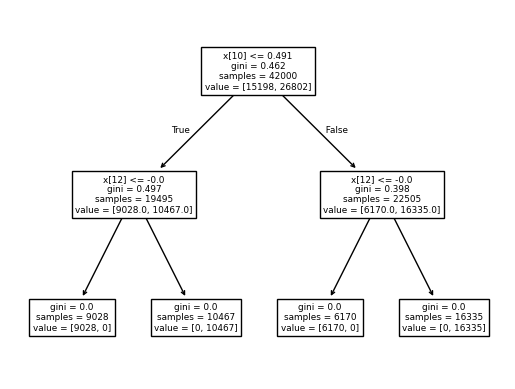

In [15]:
tree.plot_tree(best_DT_rand)

In [19]:
tree.export_graphviz(best_DT_rand, out_file="smart_grid_stability_augmented1.dot",
               feature_names=X.columns.tolist(),
               class_names=le.classes_ ,
               rounded=True, filled=True)

In [20]:
os.system("dot -Tpng smart_grid_stability_augmented1.dot -o smart_grid_stability_augmented1.png")

0